In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =========================  LOAD DATA  ===================================

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

In [4]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [5]:
df = pd.read_csv(url, header=None, names=cols)

In [6]:
# =======================   EDA   =====================================

In [7]:
df.shape

(768, 9)

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
df['Outcome'].value_counts(normalize=True) # percantage output

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [14]:
# 0: Healthy  → %65
# 1: Diabetic → %35
# Dataset is imbalanced → SMOTE will be applied later

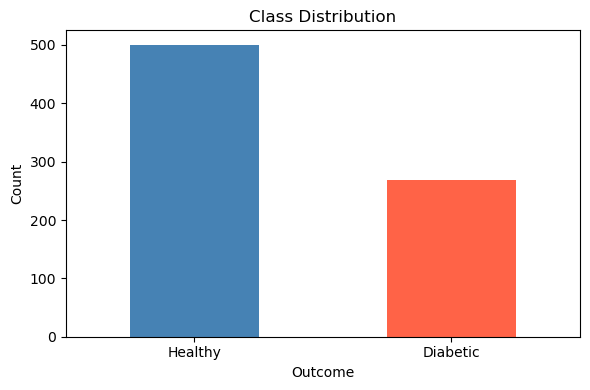

In [15]:
plt.figure(figsize=(6, 4))
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Healthy', 'Diabetic'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

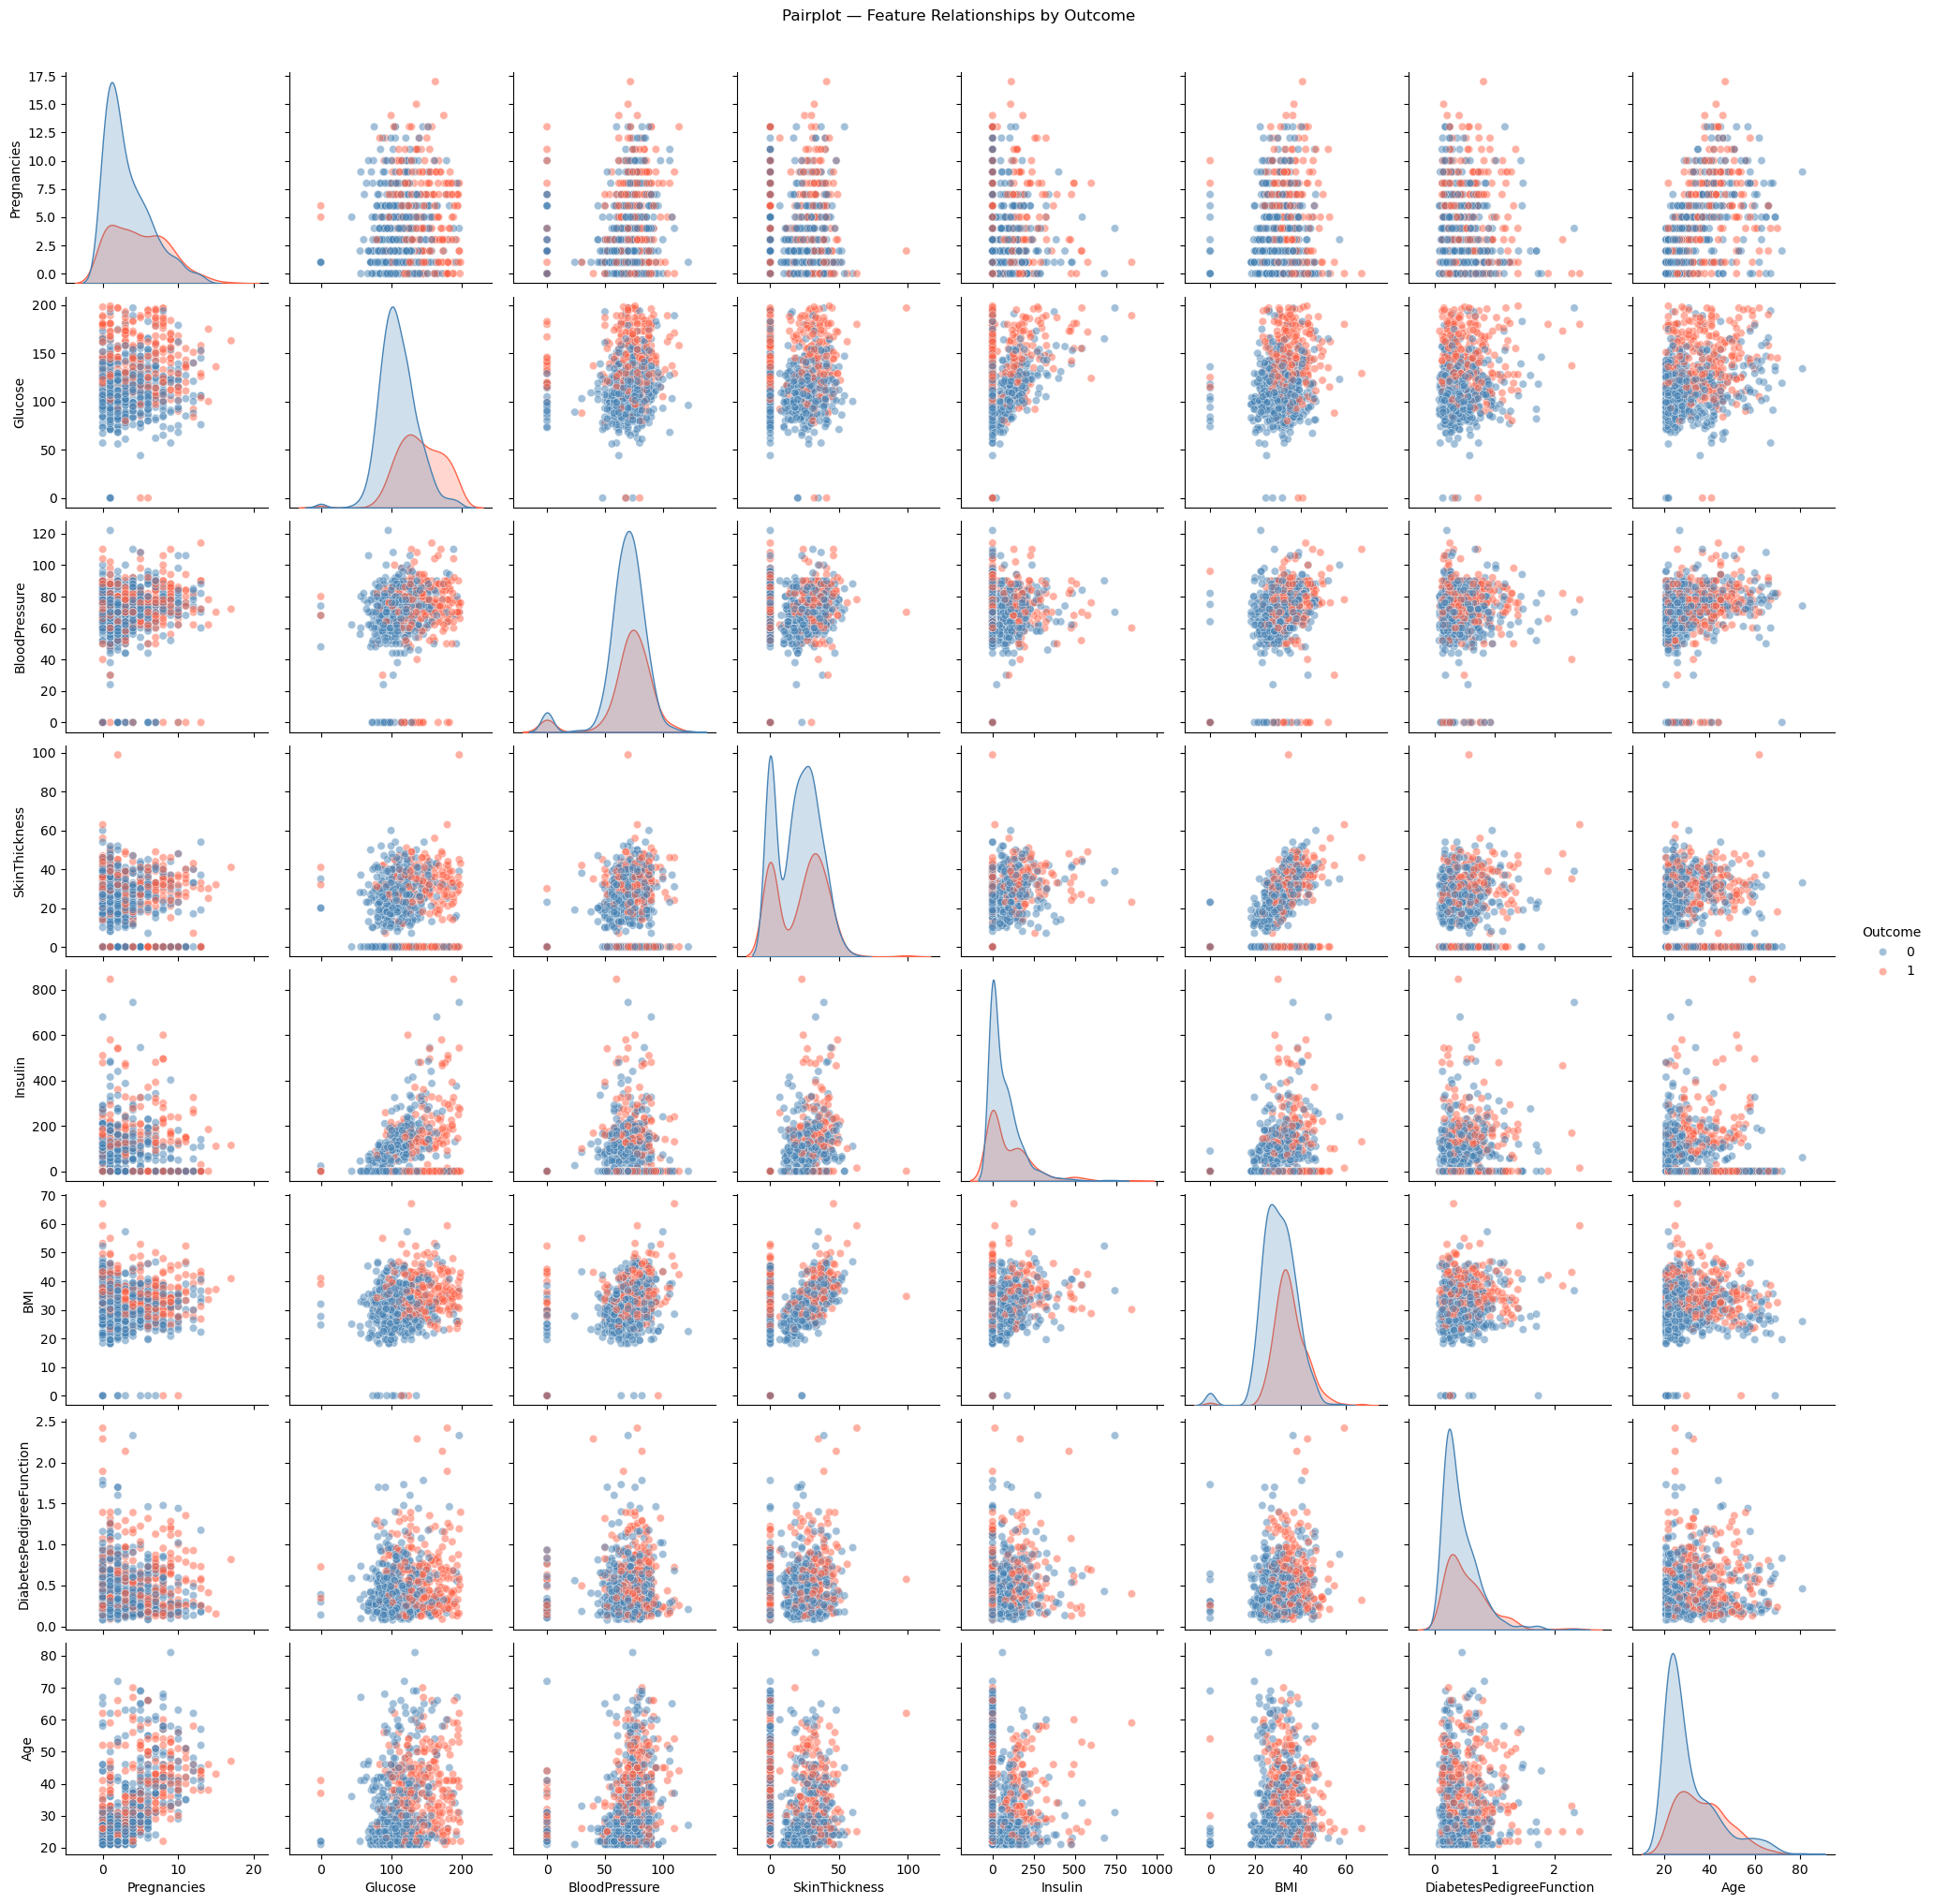

In [16]:
sns.pairplot(df, hue='Outcome', palette={0: 'steelblue', 1: 'tomato'}, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — Feature Relationships by Outcome', y=1.02)
plt.show()

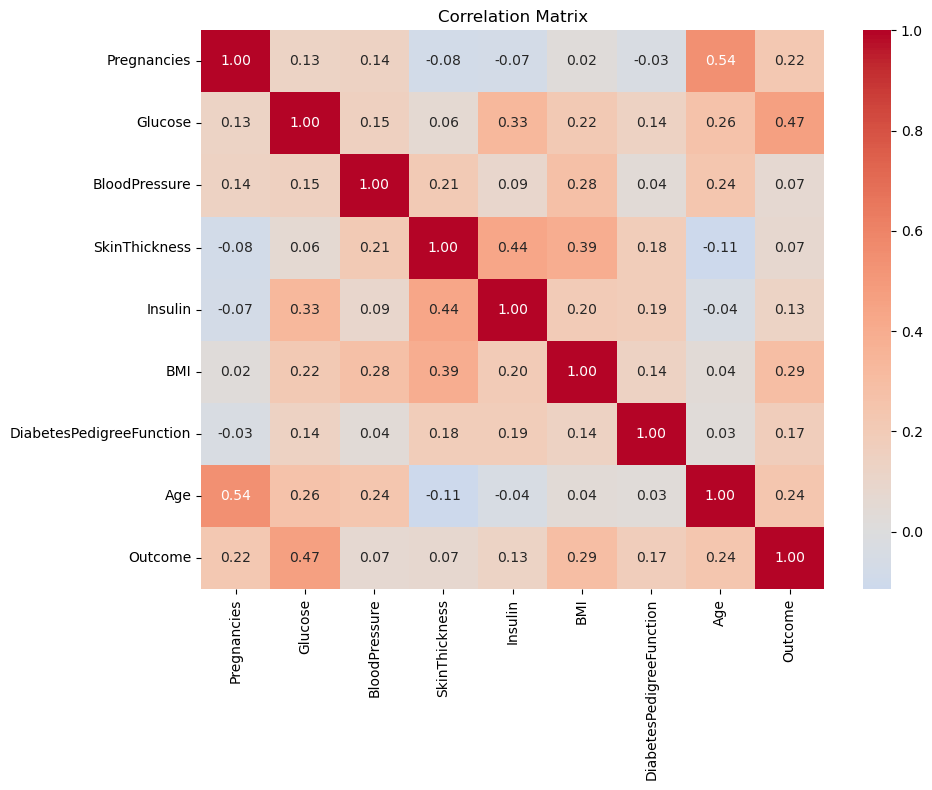

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [18]:
# VIF > 10 → serious multicollinearity, consider dropping
# VIF 5-10 → moderate, monitor
# VIF 1-5  → acceptable
# VIF = 1  → no correlation with other features

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [20]:
X_vif = df.drop("Outcome",axis=1)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

                    Feature        VIF
5                       BMI  18.408884
1                   Glucose  16.725078
2             BloodPressure  14.619512
7                       Age  13.492985
3             SkinThickness   4.008696
0               Pregnancies   3.275748
6  DiabetesPedigreeFunction   3.195626
4                   Insulin   2.063689


In [21]:
# BMI, Glucose, BloodPressure, Age → VIF > 10, multicollinearity detected
# However, these features are also highly correlated with Outcome
# Dropping them would cause information loss
# Solution: StandardScaler + L2 regularization (C parameter in LogisticRegression)

In [22]:
zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in zero_cols:
    zeros = (df[col]==0).sum()
    print(f'{col}: {zeros} zeros ({zeros/len(df)*100:.1f}%)')

Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


In [23]:
# ===================== PREPROCESSING =====================

In [24]:
df_clean = df.copy()

zero_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

#Replace 0s with Nan first
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Fill NaN with class-wise median
for col in zero_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print('Missing values after filling:')
print(df_clean.isnull().sum())


Missing values after filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [25]:
def cap_outliers(df,cols):
    df = df.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        capped = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower,upper)
        
        if capped > 0:
            print(f"{col}: {capped} outliers capped")
            
    return df

features = [col for col in df_clean.columns if col != "Outcome"]
df_clean = cap_outliers(df_clean,features)
print('Outlier capping done')

Pregnancies: 4 outliers capped
BloodPressure: 14 outliers capped
SkinThickness: 87 outliers capped
Insulin: 51 outliers capped
BMI: 8 outliers capped
DiabetesPedigreeFunction: 29 outliers capped
Age: 9 outliers capped
Outlier capping done


In [26]:
# Capping outliers with IQR method (same as linear regression notebook)
# Values below Q1-1.5*IQR or above Q3+1.5*IQR are clipped to boundary values

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X = df_clean.drop("Outcome",axis=1)
y = df_clean["Outcome"].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

print(f"X train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train class distribution: {np.bincount(y_train)}")
print(f"y_test class distribution: {np.bincount(y_test)}")


X train: (614, 8)
X_test:  (154, 8)
y_train class distribution: [400 214]
y_test class distribution: [100  54]


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")
print(f"X_train mean : {X_train_scaled.mean():.4f}" )
print(f"X_test mean : {X_test_scaled.mean():.4f}" )

Scaling done
X_train mean : -0.0000
X_test mean : 0.0177


In [30]:
# StandardScaler: mean=0, std=1
# fit_transform on train → learn mean/std from train only
# transform on test → apply train's mean/std to test (no data leakage)

In [31]:
from imblearn.over_sampling import SMOTE

In [32]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {np.bincount(y_train)}")
print(f"After SMOTE: {np.bincount(y_train_smote)}")

Before SMOTE: [400 214]
After SMOTE: [400 400]


In [33]:
# SMOTE applied only on train set — never on test!
# Applying SMOTE on test would be data leakage

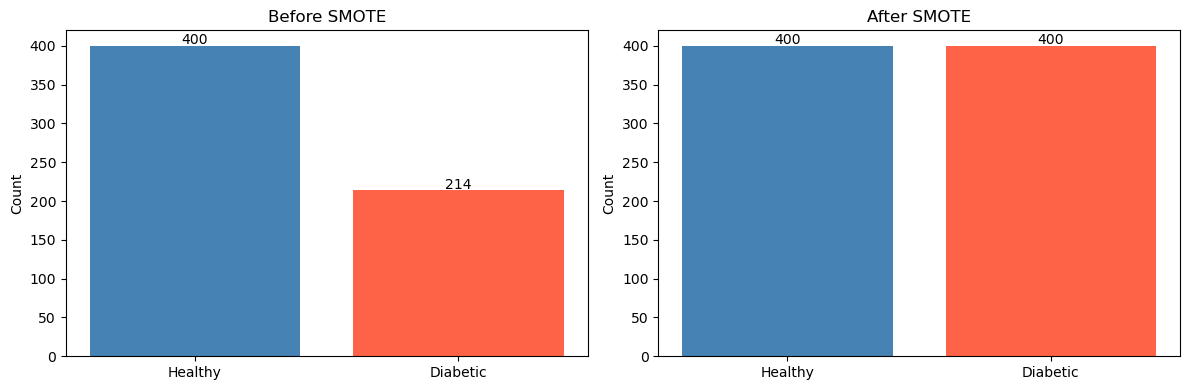

In [36]:
fig ,axes = plt.subplots(1,2, figsize=(12,4))

for ax, (data,label) in zip(axes, [
    (y_train,"Before SMOTE"),
    (y_train_smote, "After SMOTE")
]):
    counts = np.bincount(data)
    ax.bar(["Healthy","Diabetic"], counts, color=["steelblue","tomato"])
    ax.set_title(label)
    ax.set_ylabel("Count")
    for i,v in enumerate(counts):
        ax.text(i, v+2, str(v), ha="center")


plt.tight_layout()
plt.show()
    

In [37]:
# ===================== MODEL =====================

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

print("Mode trained")

Mode trained


In [40]:
# max_iter=1000 → default 100, sometimes not enough to converge
# random_state=42 → reproducibility

In [41]:
# ===================== METRICS =====================

In [42]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Diabetic']))

              precision    recall  f1-score   support

     Healthy       0.89      0.72      0.80       100
    Diabetic       0.62      0.83      0.71        54

    accuracy                           0.76       154
   macro avg       0.75      0.78      0.75       154
weighted avg       0.79      0.76      0.77       154



In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

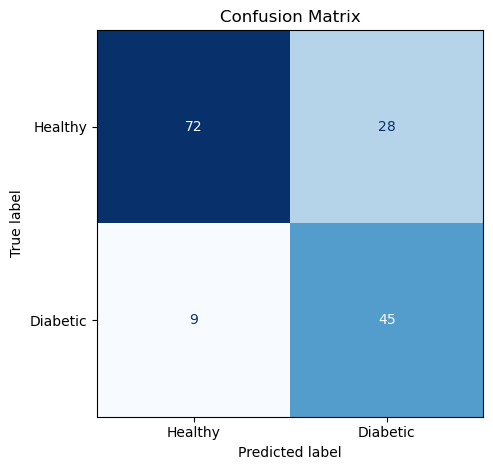

In [44]:
cm = confusion_matrix(y_test,y_pred)
disp= ConfusionMatrixDisplay(cm,display_labels=["Healthy","Diabetic"])
disp.plot(colorbar=False,cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import roc_auc_score, roc_curve

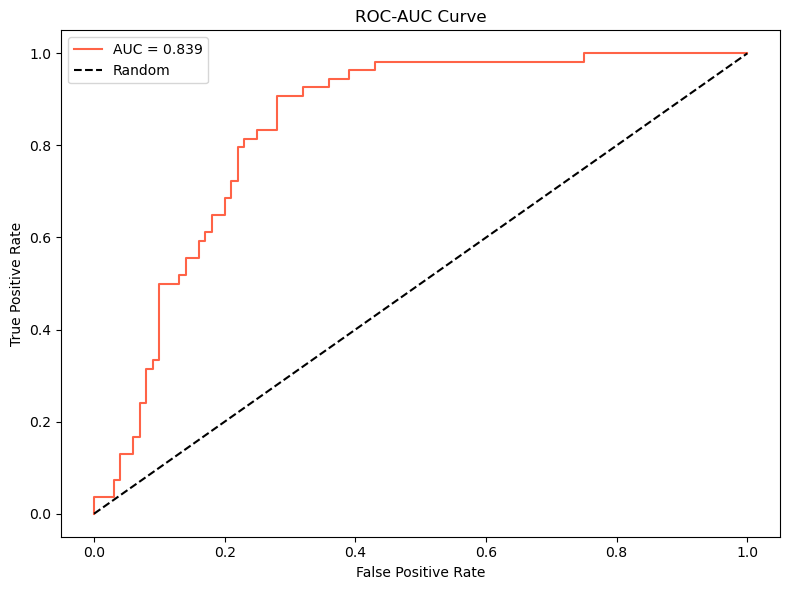

In [46]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test,y_prob)
auc = roc_auc_score(y_test,y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="tomato", label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score

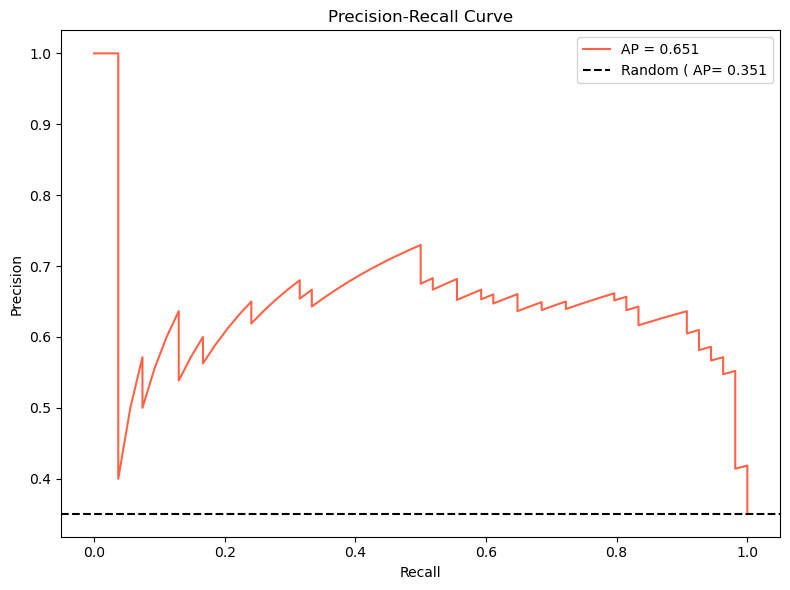

In [49]:
prec, rec, _ = precision_recall_curve(y_test,y_prob)
ap = average_precision_score(y_test,y_prob)

plt.figure(figsize=(8,6))
plt.plot(rec,prec,color = "tomato", label=f"AP = {ap:.3f}")
plt.axhline(y=y_test.mean(), color="k", linestyle="--", label=f"Random ( AP= {y_test.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
# AP (Average Precision) → area under PR curve
# Random baseline = class ratio (0.35 for our dataset)
# Higher AP → better model

In [51]:
from sklearn.metrics import  log_loss

In [52]:
l1 = log_loss(y_test,y_prob)
print(f"Log Loss: {l1:.4f}")

Log Loss: 0.5439


In [53]:
# Log Loss penalizes confident wrong predictions heavily
# Lower is better, 0 is perfect

In [54]:
from sklearn.metrics  import cohen_kappa_score

In [55]:
kappa = cohen_kappa_score(y_test,y_pred)
print(f"Cohen Kappa: {kappa:.4f}")

Cohen Kappa: 0.5119


In [56]:
# Cohen's Kappa: measures agreement beyond chance
# More reliable than accuracy for imbalanced datasets

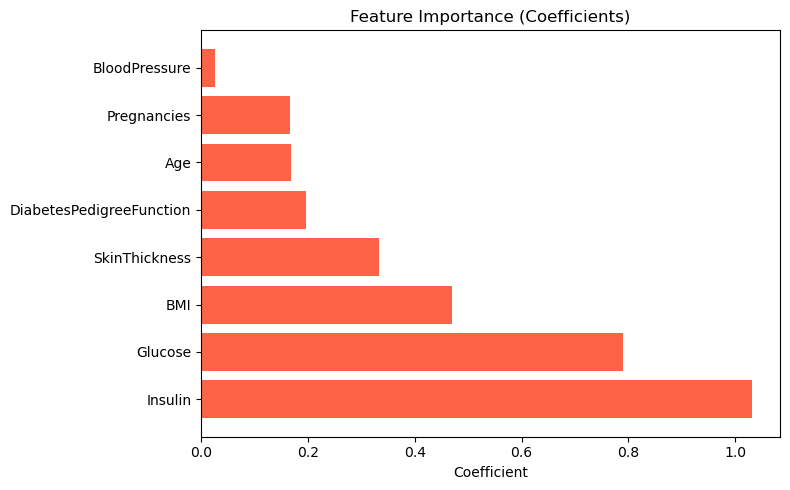

In [64]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient", key=abs,ascending=False)

plt.figure(figsize=(8,5))
colors = ["tomato" if x > 0 else "steelblue" for x in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [58]:
# Positive coefficient → increases diabetes risk
# Negative coefficient → decreases diabetes risk
# Sorted by absolute value → most important features on top

In [65]:
from sklearn.metrics import  f1_score

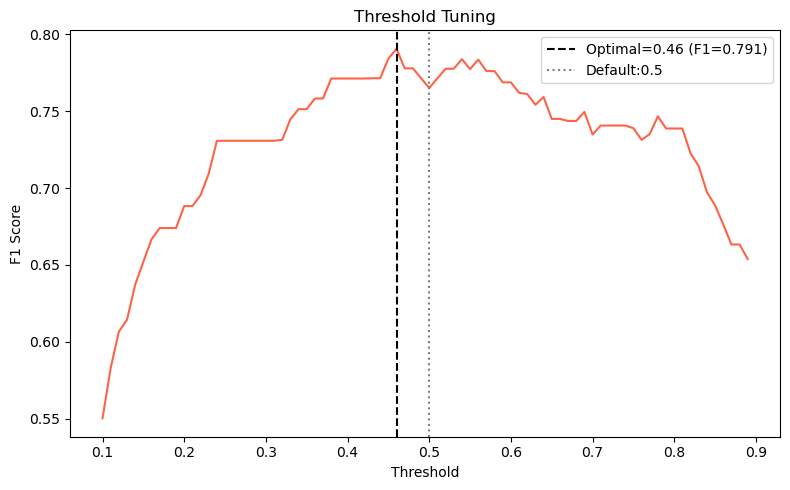

Optimal Threshold: 0.46
Optimal F1: 0.791


In [67]:
thresholds = np.arange(0.1,0.9,0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob>= t).astype(int)
    f1_scores.append(f1_score(y_test,y_pred_t, average="weighted"))

optimal_threshold = thresholds[np.argmax(f1_scores)]
optimal_f1 = max(f1_scores)

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, color = "tomato")
plt.axvline(optimal_threshold, color="black", linestyle="--",label=f"Optimal={optimal_threshold:.2f} (F1={optimal_f1:.3f})")
plt.axvline(0.5, color = "gray", linestyle=":", label="Default:0.5")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Tuning")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Optimal F1: {optimal_f1:.3f}")


In [70]:
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

print("Default Threshold (0.5):")
print(classification_report(y_test,y_pred,target_names=["Healthy","Diabetic"]))

print(f"Optimal Threshold ({optimal_threshold:.2f})")
print(classification_report(y_test,y_pred_optimal, target_names=["Healthy","Diabetic"]))

Default Threshold (0.5):
              precision    recall  f1-score   support

     Healthy       0.89      0.72      0.80       100
    Diabetic       0.62      0.83      0.71        54

    accuracy                           0.76       154
   macro avg       0.75      0.78      0.75       154
weighted avg       0.79      0.76      0.77       154

Optimal Threshold (0.46)
              precision    recall  f1-score   support

     Healthy       0.94      0.72      0.81       100
    Diabetic       0.64      0.91      0.75        54

    accuracy                           0.79       154
   macro avg       0.79      0.81      0.78       154
weighted avg       0.83      0.79      0.79       154



In [71]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

In [73]:
pipeline = ImbPipeline([
    ("smote",SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42,max_iter=1000))
])


cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

X_raw = df_clean.drop("Outcome", axis=1).values
y_raw = df_clean["Outcome"].values

cv_scores= cross_val_score(pipeline, X_raw,y_raw, cv=cv, scoring="roc_auc")

print(f"CV Scores: {cv_scores}")
print(f"mean: {cv_scores.mean():.4f}")
print(f"Std: {cv_scores.std():.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test,y_prob):.4f}")


CV Scores: [0.85259259 0.90425926 0.88555556 0.87132075 0.86132075]
mean: 0.8750
Std: 0.0183
Test ROC-AUC: 0.8389


In [72]:
# Pipeline ensures SMOTE is applied inside each fold → no data leakage
# StratifiedKFold → class ratio preserved in each fold
# If CV mean ≈ Test score → no overfitting

In [74]:
# CV Mean (0.8750) ≈ Test ROC-AUC (0.8389) → no overfitting
# Std (0.0183) → model is stable across folds
# Difference < 0.05 → acceptable

In [75]:
from sklearn.decomposition import PCA

In [76]:
# ============================== DECISION BOUNDARY (PCA 2D) ==============================

In [80]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_smote)
X_test_pca = pca.transform(X_test_scaled)

lr_pca = LogisticRegression(random_state=42,max_iter=1000)
lr_pca.fit(X_train_pca, y_train_smote)

print(f"PC1 variance: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 variance: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}")



PC1 variance: 32.4%
PC2 variance: 18.9%
Total variance explained: 51.3


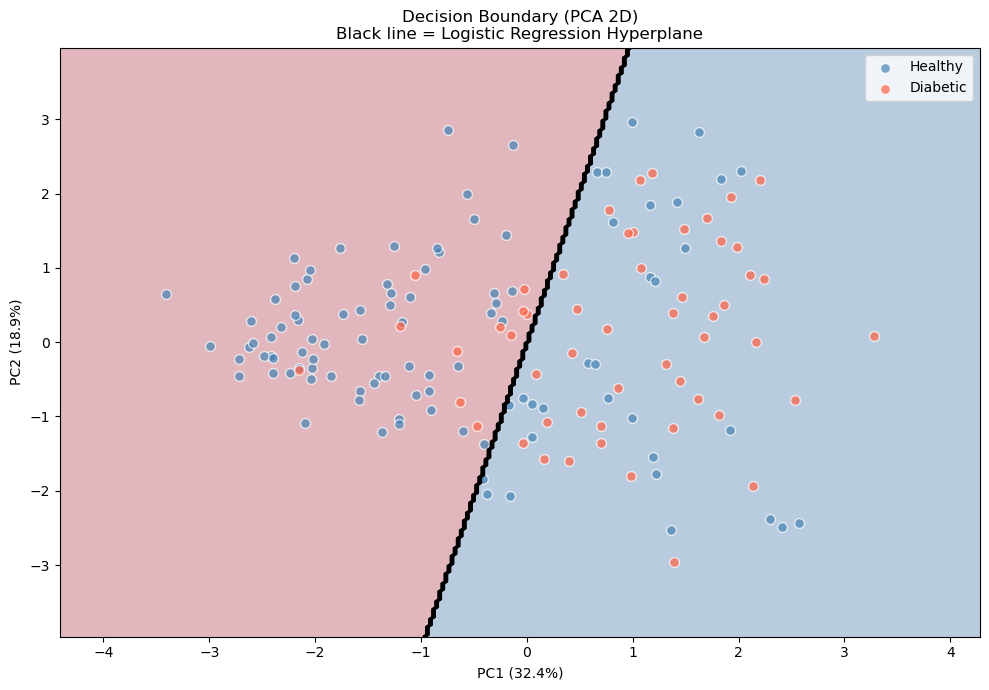

In [81]:
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

Z = lr_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.contour(xx, yy, Z, colors='black', linewidths=1.5)

plt.scatter(X_test_pca[y_test==0, 0], X_test_pca[y_test==0, 1],
            c='steelblue', label='Healthy', alpha=0.7, edgecolors='w', s=50)
plt.scatter(X_test_pca[y_test==1, 0], X_test_pca[y_test==1, 1],
            c='tomato', label='Diabetic', alpha=0.7, edgecolors='w', s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Decision Boundary (PCA 2D)\nBlack line = Logistic Regression Hyperplane')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
# ============================================================
# RESULTS SUMMARY
# ============================================================

from sklearn.metrics import accuracy_score

print('='*55)
print('RESULTS SUMMARY')
print('='*55)
print(f'Accuracy (optimal threshold):  {accuracy_score(y_test, y_pred_optimal):.4f}')
print(f'F1 Weighted (optimal):         {f1_score(y_test, y_pred_optimal, average="weighted"):.4f}')
print(f'ROC-AUC:                       {roc_auc_score(y_test, y_prob):.4f}')
print(f'Log Loss:                      {log_loss(y_test, y_prob):.4f}')
print(f'Cohen Kappa (optimal):         {cohen_kappa_score(y_test, y_pred_optimal):.4f}')
print(f'CV ROC-AUC Mean:               {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Optimal Threshold:             {optimal_threshold:.2f}')
print('='*55)
print('No overfitting detected ✅')

RESULTS SUMMARY
Accuracy (optimal threshold):  0.7857
F1 Weighted (optimal):         0.7906
ROC-AUC:                       0.8389
Log Loss:                      0.5439
Cohen Kappa (optimal):         0.5714
CV ROC-AUC Mean:               0.8750 ± 0.0183
Optimal Threshold:             0.46
No overfitting detected ✅
